# Lehtiö et al., 2021: Multimodal data integration

In modern -omics experiments, it is common to measure multiple _modalities_ at once. It is a central challenge to integrate these complementary measurements to a unified view of the biological state of the specimen. `alphapepttools` seamlessly integrates MS-proteomics data with other modalities via the shared `scverse` infrastructure. 

## Study background 

In this tutorial, we explore the integration of multiple modalities in a clinical setting by reanalysing the dataset by **Lehtiö et al., 2021**. In the original publication, the authors recorded a deep proteome of non-small cell lung cancer (NSCLC) samples from 141 patients with fractionated DDA-TMT proteomics. They identified 6 proteomic cancer subtypes and associated them with histological subtypes, immune infiltration, and clinical outcomes. Notably, they compared the proteomic subtypes post hoc with matched measurements of RNA microarray + methylation experiments from a previous publication. Here, we demonstrate how these matched -omics measurements can instead be jointly modelled in a MOFA+ analysis. 


## References

1. **Proteomics Data**: Lehtiö, J. et al. Proteogenomics of non-small cell lung cancer reveals molecular subtypes associated with specific therapeutic targets and immune-evasion mechanisms. Nat Cancer 2, 1224–1242 (2021). [PXD020191](https://www.ebi.ac.uk/pride/archive/projects/PXD020191)

2. **RNA microarray + Methylation data** Karlsson, A. et al. Genome-wide DNA Methylation Analysis of Lung Carcinoma Reveals One Neuroendocrine and Four Adenocarcinoma Epitypes Associated with Patient Outcome. Clin Cancer Res 20, 6127–6140 (2014).

## Analysis

To run this tutorial, you need to install the scverse packages `muon`, `mofapy2`, and `mofax` in your local environment

In [ ]:
# TODO: Remove
%load_ext autoreload
%autoreload 2

In [ ]:
# ! pip install muon mofapy2 mofax

In [ ]:
import anndata as ad
import alphapepttools as apt
import pandas as pd
from alphabase.pg_reader.keys import PGCols
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import seaborn as sns
import scanpy as sc
from scipy.stats import pearsonr
from alphapepttools.tl.stats import nan_safe_bh_correction

# Multimodal integration
import mudata as md
import muon

## Read and preprocess MS-proteomics data

We will first focus on the MS-proteomics data. We downloaded the gene-level aggregated data from the corresponding pride repository [PXD020191](https://www.ebi.ac.uk/pride/archive/projects/PXD020191).

### IO
In a first step, we will ingest and preprocess the MS-proteomics data separately from the other modalities. 

In [ ]:
report_path = apt.data.get_data("lehtioe2021_pg")

column_mapping = {
    PGCols.GENES: "Protein accession",
    PGCols.DESCRIPTION: "Description",
    "protein_coverage": "Coverage",
    "n_proteins": "Amount Proteins",
    PGCols.PROTEINS: "Proteins in group",
}
measurement_regex = r"^set\d{2}_tmt10plex_\d{3}[NC]?$"

adata = apt.io.read_pg_table(
    report_path,
    # TODO: change to "custom"
    search_engine="diann",
    column_mapping=column_mapping,
    measurement_regex=measurement_regex,
)
adata

/Users/lucas-diedrich/Documents/Projects/scverse/alphatools/programming/alphatools/docs/notebooks/studies/gene-symbols_table.txt already exists (46.51789855957031 MB)


AnnData object with n_obs × n_vars = 170 × 14058
    var: 'description', 'protein_coverage', 'n_proteins', 'proteins'

We obtained 170 samples with a total of 14058 unique protein groups.

Now, we read the available clinical metadata, which was extracted from the [supplementary information](https://doi.org/10.1038/s43018-021-00259-9) of the original study. 

In [ ]:
metadata_path = apt.data.get_data("lehtioe2021_metadata")
metadata = pd.read_csv(metadata_path, sep="\t", index_col="tmt_set_and_label")
metadata

/Users/lucas-diedrich/Documents/Projects/scverse/alphatools/programming/alphatools/docs/notebooks/studies/lethioe2021_metadata.tsv already exists (0.04194831848144531 MB)


,sample_id,proteome_subtype,age,sex,previous_histology,who2015_histology,ac_mrna_subtype_tcga,sqcc_mrna_subtype_tcga,nsclc_mrna_subtype_karlsson_et_al._2017,smokingstatus,...,zfhx3_mut,tmb,cancer_testis_antigens,ncps,purity,methylation_scores_overall,methylation_scores_promoter,methylationpresent,panelseqpresent,transcriptomicspresent
tmt_set_and_label,,,,,,,,,,,,,,,,,,,,,
set13_tmt10plex_129N,LU85,1,67.0,F,AC,AC,Terminal respiratory unit,NaN,5.0,Never_smoker,...,0.0,5.86458,0,8,0.30,0.491897,0.158030,True,True,True
set13_tmt10plex_128C,LU277,1,80.0,F,AC,AC,Terminal respiratory unit,NaN,5.0,Never_smoker,...,0.0,2.93229,2,5,0.25,0.525326,0.176840,True,True,True
set07_tmt10plex_126,LU376,1,72.0,M,AC,AC,Terminal respiratory unit,NaN,9.0,Never_smoker,...,0.0,2.93229,0,2,0.18,0.510334,0.170185,True,True,True
set11_tmt10plex_129C,LU1115,1,80.0,M,AC,AC,Terminal respiratory unit,NaN,5.0,Never_smoker,...,0.0,5.86458,4,5,0.31,0.505183,0.163569,True,True,True
set12_tmt10plex_128N,LU804,1,73.0,F,AC,AC,Terminal respiratory unit,NaN,5.0,Never_smoker,...,0.0,5.27812,1,7,0.38,0.533692,0.181161,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
set04_tmt10plex_128C,LU745,6,70.0,M,SqCC,SqCC,NaN,Classical,2.0,Former,...,0.0,8.79687,2,22,0.62,NaN,NaN,False,True,True
set14_tmt10plex_128C,LU1020,6,80.0,M,SqCC,SqCC,NaN,Classical,2.0,Former,...,0.0,24.04480,5,13,0.57,0.486081,0.154912,True,True,True
set06_tmt10plex_129C,LU372,6,69.0,M,SqCC,SqCC,NaN,Classical,2.0,Current,...,0.0,15.24790,9,27,0.68,0.437679,0.136954,True,True,True


We add the metadata to the anndata object with `alphapepttools.pp.add_metadata` and extract batch information (`tmt_plex`) from the TMT sample id. 

In [ ]:
adata = apt.pp.add_metadata(adata, metadata, axis=0, keep_data_shape=False)
adata.obs = adata.obs.reset_index(names="tmt_sample_id").set_index("sample_id")
adata.obs["tmt_plex"] = adata.obs["tmt_sample_id"].str.extract("set([0-9]+)_")[0].tolist()
adata.obs["tmt_channel"] = adata.obs["tmt_sample_id"].str.extract("_([A-Za-z0-9]+)$")[0].tolist()
adata

AnnData object with n_obs × n_vars = 141 × 14058
    obs: 'tmt_sample_id', 'proteome_subtype', 'age', 'sex', 'previous_histology', 'who2015_histology', 'ac_mrna_subtype_tcga', 'sqcc_mrna_subtype_tcga', 'nsclc_mrna_subtype_karlsson_et_al._2017', 'smokingstatus', 'smokingstatus_binary', 'stage_general', 'stage_detailed', 'os_years', 'osbin', 'relapse_years', 'relapse_bin', 'adjuvant_therapy', 'pdl1_ihc', 'cd3_stromal_ihc', 'cd8_stromal_ihc', 'stroma_estimate', 'immune_estimate', 'arid1a_mut', 'arid2_mut', 'asxl1_mut', 'atm_mut', 'blm_mut', 'braf_mut', 'cdkn2a_mut', 'egfr_mut', 'fat1_mut', 'keap1_mut', 'kmt2c_mut', 'kmt2d_mut', 'kras_mut', 'nf1_mut', 'nfe2l2_mut', 'notch2_mut', 'pik3ca_mut', 'pold1_mut', 'pten_mut', 'rb1_mut', 'rbm10_mut', 'smarca4_mut', 'stk11_mut', 'tp53_mut', 'zfhx3_mut', 'tmb', 'cancer_testis_antigens', 'ncps', 'purity', 'methylation_scores_overall', 'methylation_scores_promoter', 'methylationpresent', 'panelseqpresent', 'transcriptomicspresent', 'tmt_plex', 'tmt_chan

The study design included 16 rotating in-set references, and one full reference set (Set17). These samples were used for normalization and QC, but do not contain biological information (i.e. they lack from the metadata table). They got removeed by the `apt.pp.add_metadata` call, yielding 141 biological samples.

### Quality control + Preprocessing

To evaluate between-run variation, we check the missingness patterns of each batch. Note that we do not look at sample-level aggregates of intensity values as the data has already been transformed by the search engine (see methods of the original paper) and aggregated intensity values are difficult to interpret at this stage.

In [ ]:
apt.metrics.fraction_complete(adata, axis="obs", column="fraction_complete_obs")
apt.metrics.fraction_complete(adata, axis="var", column="fraction_complete_var")

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_64233/1164706306.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


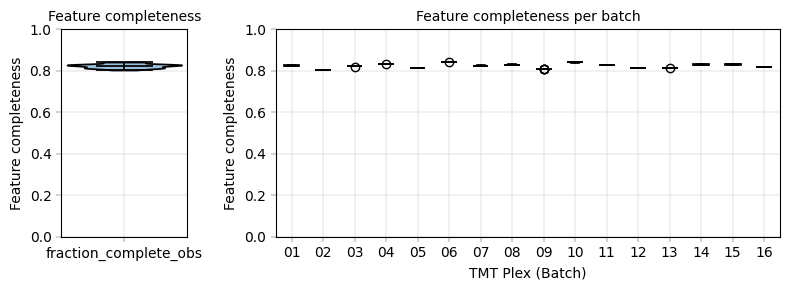

In [ ]:
fig, axm = apt.pl.create_figure(1, 2, figsize=(8, 3), width_ratios=(1, 4))

apt.pl.violinplot(ax=axm[0], data=adata, direct_columns=["fraction_complete_obs"])
apt.pl.label_axes(ax=axm[0], xlabel=None, ylabel="Feature completeness", title="Feature completeness")
axm[0].set_ylim(0.0, 1.0)


apt.pl.boxplot(ax=axm[1], data=adata, grouping_column="tmt_plex", value_column="fraction_complete_obs")

apt.pl.label_axes(
    ax=axm[1], xlabel="TMT Plex (Batch)", ylabel="Feature completeness", title="Feature completeness per batch"
)
axm[1].set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()

We observe a low variability of the feature missingness between samples and between batches, indicating a good comparability of the samples between batches.

We also look at the feature-wise missingness: Most features are 100% complete, suggesting a deep proteome profiling

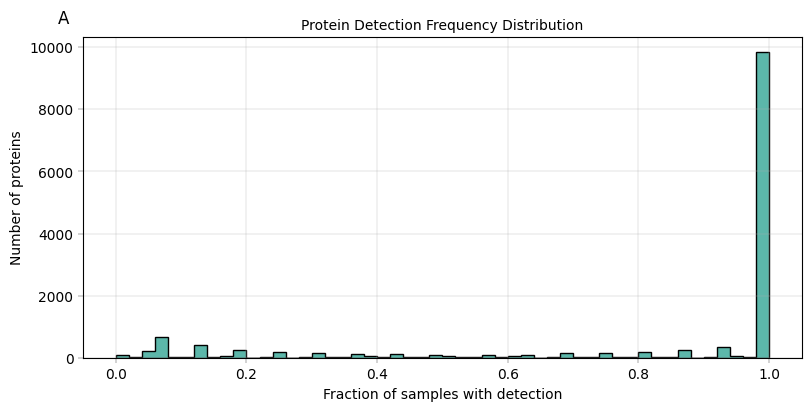

In [ ]:
# Histogram of detection frequency combined with a rank plot
fig, axm = apt.pl.create_figure(1, 1, figsize=(8, 4))

# Histogram
ax = axm.next()
apt.pl.histogram(
    data=adata,
    value_column="fraction_complete_var",
    bins=50,
    ax=ax,
    color=apt.pl.BaseColors.get("green"),
    hist_kwargs={"histtype": "stepfilled", "edgecolor": "black"},
)

apt.pl.label_axes(
    ax,
    xlabel="Fraction of samples with detection",
    ylabel="Number of proteins",
    title="Protein Detection Frequency Distribution",
    enumeration="A",
)

Following the original study, we drop all incomplete features.

In [ ]:
adata = apt.pp.filter_data_completeness(adata, max_missing=0, action="drop")

INFO:root:pp.filter_data_completeness(): drop 4265 / 14058 features with >0.00 missing.


### Preprocessing

We follow the original preprocessing steps and perform log2-transformation with `alphapepttools.pp.nanlog` and median centering of the features. We store the intermediate results in separate layers of the anndata object.

In [ ]:
adata.layers["raw"] = adata.X.copy()

In [ ]:
apt.pp.nanlog(adata)
adata.layers["log2"] = adata.X.copy()

In [ ]:
adata.X = (adata.X - np.nanmedian(adata.X, axis=0)).copy()
adata.layers["median_centered"] = adata.X.copy()

#### Visual inspection 
We check the data qualitatively and investigate whether histological subtypes separate, representing expected biological variation.

In [ ]:
apt.tl.pca(adata)

INFO:alphapepttools.tl.embeddings:computing PCA


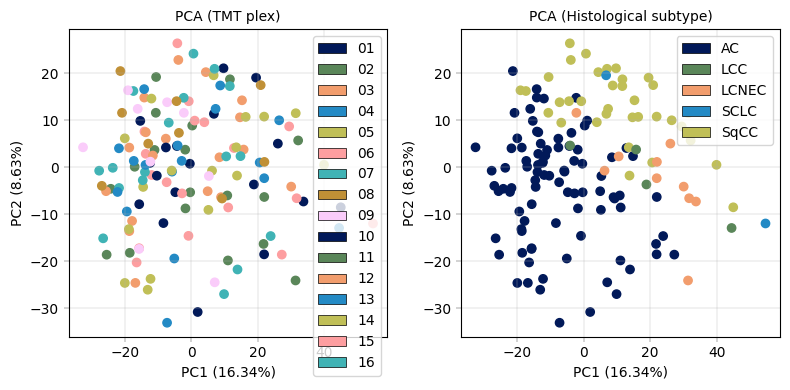

In [ ]:
fig, axm = apt.pl.create_figure(1, 2, figsize=(8, 4))


apt.pl.plot_pca(adata, y_column=2, ax=axm[0], color_map_column="tmt_plex", legend="auto")
apt.pl.label_axes(ax=axm[0], title="PCA (TMT plex)")


apt.pl.plot_pca(adata, y_column=2, ax=axm[1], color_map_column="who2015_histology", legend="auto")
apt.pl.label_axes(ax=axm[1], title="PCA (Histological subtype)")

plt.tight_layout()

Indeed, as expected, the data separates based on histological subtypes and not TMT runs.

## Multimodal Analysis | Integrate with complementary modalities

In the original paper, the proteomics data was clustered and the proteomic phenotypes were associated post-hoc with complementary RNA and methylation microarray data. 

Here, we try to model these different modalities all at once with a MOFA+ analysis. MOFA+ is a probabilistic latent factor model that tries to identify shared axes of variation in a multi-modal dataset. Similar to other matrix factorization techniques like principal component analysis, MOFA+ assumes that the joint observed -omics measurements $X$ of $P$ features in $N$ samples can be explained by a small number ($K$) of unobserved, latent variables, that are associated with specific biological processes in the sample:

$$
    X^{N\times P} = A^{N\times K} \times L^{K\times P} + \varepsilon
$$

MOFA+ returns an estimate of the  _activity_ $A$ of these latent factors in the individual samples as a $N$ sample $\times$ $K$ latent factors matrix and the _factor loadings_ matrix $L$ of the shape $K$ factors $\times$ $P$ features. 
As all modalities are jointly modelled, the factor loadings contain estimates of the model about which features are coregulated across all -omics layers.


### References

- **MOFA+** Argelaguet, R. et al. MOFA+: a statistical framework for comprehensive integration of multi-modal single-cell data. Genome Biol 21, 111 (2020).
- **muon**: Bredikhin, D., Kats, I. & Stegle, O. MUON: multimodal omics analysis framework. Genome Biology 23, 42 (2022).


### Load complementary modalities

First, we load the other available -omics measurements. Note that we obtained the preprocessed data from the supplementary information of the original paper and used `anndata.read_excel` to convert the datasets into anndata objects.

### RNA

We download the data and read the anndata object

In [ ]:
rna_path = apt.data.get_data("lehtioe2021_rna")
rna = ad.read_h5ad(rna_path)
rna

/Users/lucas-diedrich/Documents/Projects/scverse/alphatools/programming/alphatools/docs/notebooks/studies/karlsson2014_nslc_rna.h5ad already exists (13.766532897949219 MB)


AnnData object with n_obs × n_vars = 118 × 14548
    obs: 'proteome_subtype', 'age', 'sex', 'previous_histology', 'who2015_histology', 'ac_mrna_subtype_tcga', 'sqcc_mrna_subtype_tcga', 'nsclc_mrna_subtype_karlsson_et_al._2017', 'smokingstatus', 'smokingstatus_binary', 'stage_general', 'stage_detailed', 'os_years', 'osbin', 'relapse_years', 'relapse_bin', 'adjuvant_therapy', 'pdl1_ihc', 'cd3_stromal_ihc', 'cd8_stromal_ihc', 'stroma_estimate', 'immune_estimate', 'arid1a_mut', 'arid2_mut', 'asxl1_mut', 'atm_mut', 'blm_mut', 'braf_mut', 'cdkn2a_mut', 'egfr_mut', 'fat1_mut', 'keap1_mut', 'kmt2c_mut', 'kmt2d_mut', 'kras_mut', 'nf1_mut', 'nfe2l2_mut', 'notch2_mut', 'pik3ca_mut', 'pold1_mut', 'pten_mut', 'rb1_mut', 'rbm10_mut', 'smarca4_mut', 'stk11_mut', 'tp53_mut', 'zfhx3_mut', 'tmb', 'cancer_testis_antigens', 'ncps', 'purity', 'methylation_scores_overall', 'methylation_scores_promoter', 'methylationpresent', 'panelseqpresent', 'transcriptomicspresent'

### Methylation 
Next, we load the methylation data. We need to convert the available $\beta$ values (representing the fraction of methylated CpG sites with methylation among all measurements for a certain site) to $M$-values, to match MOFA+'s expectation that the data is approximately normally distributed. See this [recommendation](https://github.com/bioFAM/MOFA/issues/44) by the authors

In [ ]:
def mvalue(adata: ad.AnnData, *, alpha: float = 0.01, layer: str | None = None, copy: bool = False) -> ad.AnnData:
    r"""Conversion of methylation beta values to M values

    .. math::

        M = \log_{2}{\frac{\beta + \alpha}{(1-\beta) + \alpha}}


    Parameters
    ----------
    adata
        AnnData object
    alpha
        Pseudocount added to the data to prevent infinite values
    layer
        Layer to act on. If `None`, uses adata.X
    copy
        If `True`, returns a copy of the anndata object, else modifies the object inplace

    References
    ----------
    - Du, P., Zhang, X., Huang, CC. et al.
    Comparison of Beta-value and M-value methods for quantifying methylation levels by microarray analysis.
    BMC Bioinformatics 11, 587 (2010). https://doi.org/10.1186/1471-2105-11-587
    - Ricard Argelaguet (GitHub): https://github.com/bioFAM/MOFA/issues/44

    """
    adata = adata.copy() if copy else adata
    data = adata.X if layer is None else adata.layers[layer]

    data = np.log2((data + alpha) / ((1 - data) + alpha))

    if layer is None:
        adata.X = data
    else:
        adata.layers[layer] = data

    return adata if copy else None

In [ ]:
methylation_path = apt.data.get_data("lehtioe2021_methylation")
methylation = ad.read_h5ad(methylation_path)

methylation.layers["beta_values"] = methylation.X.copy()
# Convert beta values to M-values
# See recommendation by original authors: https://github.com/bioFAM/MOFA/issues/44#issuecomment-526280692
mvalue(methylation, alpha=0.01, layer=None, copy=False)
methylation

/Users/lucas-diedrich/Documents/Projects/scverse/alphatools/programming/alphatools/docs/notebooks/studies/karlsson2014_nslc_methylation.h5ad already exists (12.006929397583008 MB)


/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 113 × 11937
    obs: 'proteome_subtype', 'age', 'sex', 'previous_histology', 'who2015_histology', 'ac_mrna_subtype_tcga', 'sqcc_mrna_subtype_tcga', 'nsclc_mrna_subtype_karlsson_et_al._2017', 'smokingstatus', 'smokingstatus_binary', 'stage_general', 'stage_detailed', 'os_years', 'osbin', 'relapse_years', 'relapse_bin', 'adjuvant_therapy', 'pdl1_ihc', 'cd3_stromal_ihc', 'cd8_stromal_ihc', 'stroma_estimate', 'immune_estimate', 'arid1a_mut', 'arid2_mut', 'asxl1_mut', 'atm_mut', 'blm_mut', 'braf_mut', 'cdkn2a_mut', 'egfr_mut', 'fat1_mut', 'keap1_mut', 'kmt2c_mut', 'kmt2d_mut', 'kras_mut', 'nf1_mut', 'nfe2l2_mut', 'notch2_mut', 'pik3ca_mut', 'pold1_mut', 'pten_mut', 'rb1_mut', 'rbm10_mut', 'smarca4_mut', 'stk11_mut', 'tp53_mut', 'zfhx3_mut', 'tmb', 'cancer_testis_antigens', 'ncps', 'purity', 'methylation_scores_overall', 'methylation_scores_promoter', 'methylationpresent', 'panelseqpresent', 'transcriptomicspresent'
    var: 'probeID', 'ID'
    layers: 'b

### Create mudata object

To jointly represent the cohort across all -omics layers, we create a [`mudata`](https://mudata.readthedocs.io/stable/) object. `mudata` binds multiple modalities, represented as [`anndata`](../tutorials/tutorial_00_data_sources.ipynb) objects, into a single container. Each modality fits into a `.mod` slot of the object, and the resulting data structure behaves very similarly to the familiar anndata containers.

In [ ]:
mdata = md.MuData({"proteins": adata, "rna": rna, "methylation": methylation})

# We remove columns with missing values
mdata.obs = mdata.obs.merge(metadata.set_index("sample_id"), left_index=True, right_index=True).dropna(axis=1)
mdata.var["modality"] = (
    pd.DataFrame.from_dict({key: mdata.varmap[key].squeeze() for key in mdata.varmap}).idxmax(axis=1).tolist()
)

mdata

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:571: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:571: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/

MuData object with n_obs × n_vars = 141 × 36278
  obs:	'proteome_subtype', 'age', 'sex', 'previous_histology', 'who2015_histology', 'smokingstatus', 'smokingstatus_binary', 'os_years', 'osbin', 'stroma_estimate', 'immune_estimate', 'cancer_testis_antigens', 'ncps', 'methylationpresent', 'panelseqpresent', 'transcriptomicspresent'
  var:	'modality'
  3 modalities
    proteins:	141 x 9793
      obs:	'tmt_sample_id', 'proteome_subtype', 'age', 'sex', 'previous_histology', 'who2015_histology', 'ac_mrna_subtype_tcga', 'sqcc_mrna_subtype_tcga', 'nsclc_mrna_subtype_karlsson_et_al._2017', 'smokingstatus', 'smokingstatus_binary', 'stage_general', 'stage_detailed', 'os_years', 'osbin', 'relapse_years', 'relapse_bin', 'adjuvant_therapy', 'pdl1_ihc', 'cd3_stromal_ihc', 'cd8_stromal_ihc', 'stroma_estimate', 'immune_estimate', 'arid1a_mut', 'arid2_mut', 'asxl1_mut', 'atm_mut', 'blm_mut', 'braf_mut', 'cdkn2a_mut', 'egfr_mut', 'fat1_mut', 'keap1_mut', 'kmt2c_mut', 'kmt2d_mut', 'kras_mut', 'nf1_mut', 'nfe2l2_mut', 'notch2_mut', 'pik3ca_mut', 'pold1_mut', 'pten_mut', 'rb1_mut', 'rbm10_mut', 'smarca4_mut', 'stk11_mut', 'tp53_mut', 'zfhx3_mut', 'tmb', 'cancer_testis_antigens', 'ncps', 'purity', 'methylation_scores_overall', 'methylation_scores_promoter', 'methylationpresent', 'panelseqpresent', 'transcriptomicspresent', 'tmt_plex', 'tmt_channel', 'fraction_complete_obs'
      var:	'description', 'protein_coverage', 'n_proteins', 'proteins', 'fraction_complete_var'
      uns:	'variance_pca_obs'
      obsm:	'X_pca_obs'
      varm:	'PCs_pca_obs'
      layers:	'raw', 'log2', 'median_centered'
    rna:	118 x 14548
      obs:	'proteome_subtype', 'age', 'sex', 'previous_histology', 'who2015_histology', 'ac_mrna_subtype_tcga', 'sqcc_mrna_subtype_tcga', 'nsclc_mrna_subtype_karlsson_et_al._2017', 'smokingstatus', 'smokingstatus_binary', 'stage_general', 'stage_detailed', 'os_years', 'osbin', 'relapse_years', 'relapse_bin', 'adjuvant_therapy', 'pdl1_ihc', 'cd3_stromal_ihc', 'cd8_stromal_ihc', 'stroma_estimate', 'immune_estimate', 'arid1a_mut', 'arid2_mut', 'asxl1_mut', 'atm_mut', 'blm_mut', 'braf_mut', 'cdkn2a_mut', 'egfr_mut', 'fat1_mut', 'keap1_mut', 'kmt2c_mut', 'kmt2d_mut', 'kras_mut', 'nf1_mut', 'nfe2l2_mut', 'notch2_mut', 'pik3ca_mut', 'pold1_mut', 'pten_mut', 'rb1_mut', 'rbm10_mut', 'smarca4_mut', 'stk11_mut', 'tp53_mut', 'zfhx3_mut', 'tmb', 'cancer_testis_antigens', 'ncps', 'purity', 'methylation_scores_overall', 'methylation_scores_promoter', 'methylationpresent', 'panelseqpresent', 'transcriptomicspresent'
    methylation:	113 x 11937
      obs:	'proteome_subtype', 'age', 'sex', 'previous_histology', 'who2015_histology', 'ac_mrna_subtype_tcga', 'sqcc_mrna_subtype_tcga', 'nsclc_mrna_subtype_karlsson_et_al._2017', 'smokingstatus', 'smokingstatus_binary', 'stage_general', 'stage_detailed', 'os_years', 'osbin', 'relapse_years', 'relapse_bin', 'adjuvant_therapy', 'pdl1_ihc', 'cd3_stromal_ihc', 'cd8_stromal_ihc', 'stroma_estimate', 'immune_estimate', 'arid1a_mut', 'arid2_mut', 'asxl1_mut', 'atm_mut', 'blm_mut', 'braf_mut', 'cdkn2a_mut', 'egfr_mut', 'fat1_mut', 'keap1_mut', 'kmt2c_mut', 'kmt2d_mut', 'kras_mut', 'nf1_mut', 'nfe2l2_mut', 'notch2_mut', 'pik3ca_mut', 'pold1_mut', 'pten_mut', 'rb1_mut', 'rbm10_mut', 'smarca4_mut', 'stk11_mut', 'tp53_mut', 'zfhx3_mut', 'tmb', 'cancer_testis_antigens', 'ncps', 'purity', 'methylation_scores_overall', 'methylation_scores_promoter', 'methylationpresent', 'panelseqpresent', 'transcriptomicspresent'
      var:	'probeID', 'ID'
      layers:	'beta_values'

### Run MOFA+ factor analysis 

MOFA+ can be run with the `muon` framework. Here, we define some parameters of the MOFA+ object, largely following the [recommendations](https://biofam.github.io/MOFA2/faq.html) of the authors and default settings.

In addition, we model all samples, even if a modality is missing `"use_obs": "union"` to leverage the full dataset, and assume that all modalities are normally distributed (`"likelihoods": "gaussian"`). The assumption of a gaussian distribution is acceptable as we log-transformed the data beforehand. 

In total, we model 25 factors (`"n_factors": 25`), which is in line with the assumption that at most 25 different latent processes explain the observed -omics measurements. By setting `ard_factors` to `True`, MOFA+ automatically regularizes the usage of the factors, i.e. the activities of unnecessary factors are shrunken to values close to zero

In [ ]:
mofa_kwargs = {
    "use_obs": "union",  # Use all available samples
    "n_factors": 25,  # 25 factors
    # Use defaults as recommended by the authors
    "scale_groups": True,
    "scale_views": True,
    "ard_factors": True,
    "ard_weights": True,
    "spikeslab_weights": True,
    "spikeslab_factors": True,
    "likelihoods": "gaussian",
    # Fitting parameters - set seed to 1 for reproducibility
    "convergence_mode": "slow",
    "seed": 1,
}

# Runs 5min on MacOS + M4
# ard_weights: True, as only a multiple views are provided
muon.tl.mofa(mdata, **mofa_kwargs, outfile="mofa-multimodal.model.hdf5")
mdata.write_h5mu("./mdata.h5mu")


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Scaling views to unit variance...

Scaling groups to unit variance...

Loaded view='proteins' group='group1' with N=141 samples and D=9793 features...
Loaded view='rna' group='group1' with N=141 samples and D=14548 features...
Loaded view='methylation' group='group1' with N=141 samples and D=11937 features...


Model options:
- Automatic Relevance Determination prior on the factors: Tr

... storing 'sex' as categorical
... storing 'previous_histology' as categorical
... storing 'who2015_histology' as categorical
... storing 'smokingstatus' as categorical
... storing 'smokingstatus_binary' as categorical
... storing 'modality' as categorical
... storing 'sex' as categorical
... storing 'previous_histology' as categorical
... storing 'who2015_histology' as categorical
... storing 'ac_mrna_subtype_tcga' as categorical
... storing 'sqcc_mrna_subtype_tcga' as categorical
... storing 'smokingstatus' as categorical
... storing 'smokingstatus_binary' as categorical
... storing 'stage_general' as categorical
... storing 'stage_detailed' as categorical
... storing 'adjuvant_therapy' as categorical
... storing 'tmt_plex' as categorical
... storing 'tmt_channel' as categorical
... storing 'n_proteins' as categorical


Saved MOFA embeddings in .obsm['X_mofa'] slot and their loadings in .varm['LFs'].


... storing 'probeID' as categorical


## Exploration
We can explore the fitted MOFA+ model

### Plot explained variance as proxy for relevance 
MOFA+ provides an estimate of how much variance is explained by each modality and each factor which we can extract and plot. This gives us an idea of which factors explain a relevant amount of the data and which factors we should prioritize in the downstream analysis.

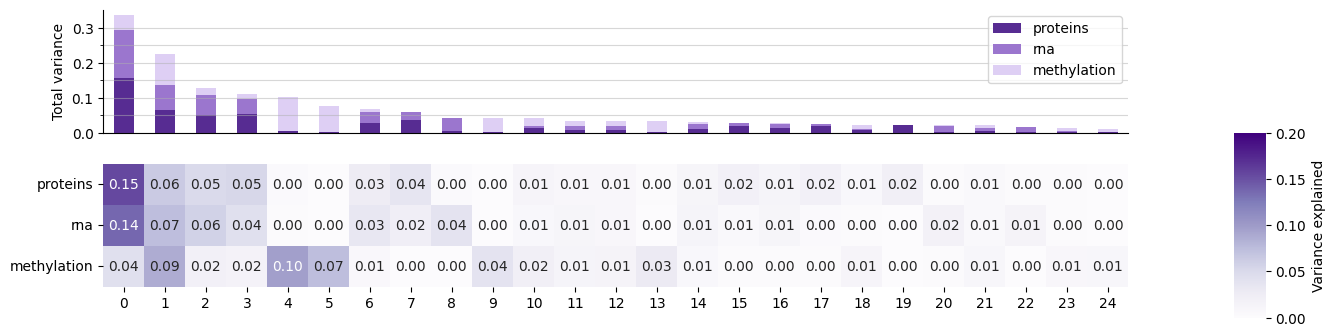

In [ ]:
explained_variance = (
    pd.DataFrame.from_dict(mdata.uns["mofa"]["variance"], orient="index") / 100
)  # (MOFA+ reports in percent, we scale to floats)

fig, axs = plt.subplots(
    2,
    2,
    figsize=(15, 4),
    gridspec_kw={"height_ratios": [0.4, 0.6], "width_ratios": [0.97, 0.03], "hspace": 0},
    squeeze=True,
)

explained_variance.T.plot.bar(ax=axs[0, 0], color=["#572c92", "#9b76ce", "#decff4"], stacked=True)
axs[0, 0].set_xticks([])
axs[0, 0].set_yticks(np.arange(0, 0.31, 0.05), minor=True)
axs[0, 0].grid(axis="y", alpha=0.5, which="minor")
axs[0, 0].grid(axis="y", alpha=0.5, which="major")

axs[0, 0].spines[["top", "right"]].set_visible(False)
axs[0, 0].set_ylabel("Total variance")
axs[0, 1].set_axis_off()


sns.heatmap(
    explained_variance,
    square=True,
    annot=True,
    fmt=".2f",
    ax=axs[1, 0],
    cbar_ax=axs[1, 1],
    cbar_kws={"shrink": 0.1, "label": "Variance explained"},
    vmin=0,
    vmax=0.2,
    cmap="Purples",
)

plt.show()

We see that the first ~7 factors each explain more than 5% of variance. We can also see that some factors share variance across all modalities (most prominently factor 1), while in other cases, the explained variance is dominated by certain modalities. For example, factor 0, 2, and 3  are dominated by the RNA and Protein modalities, while factors 4 and 5 are only relevant for the methylation measurements.

### Factor activity analysis 

We can plot the MOFA+ embeddings similar to a PCA. Note that we plot the 1rst and 3rd component of the MOFA+ embedding, as the 2nd component does not capture variation aligned with histological differences:

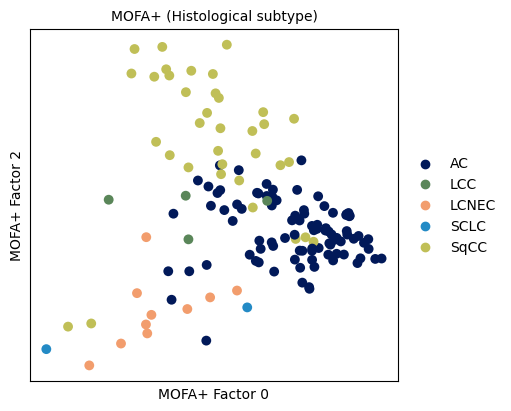

In [ ]:
fig, axm = apt.pl.create_figure(1, 1, figsize=(5, 4))

muon.pl.embedding(
    mdata,
    basis="X_mofa",
    color="who2015_histology",
    dimensions=(0, 2),
    palette=apt.pl.BasePalettes().get("qualitative"),
    size=200,
    ax=axm[0],
    title="",
    show=False,
)

apt.pl.label_axes(title="MOFA+ (Histological subtype)", xlabel="MOFA+ Factor 0", ylabel="MOFA+ Factor 2", ax=axm[0])

We see that factor 2 separates the subtypes squamous cell carcinoma, adenocarcinoma, and LCNEC particularly well. 

#### Association with clinical metadata

To further prioritize clinically relevant factors, we associate the factors with the available clinical metadata.

In [ ]:
continuous_covariates = ("os_years", "relapse_years")
categorical_covariates = ("who2015_histology",)
metadata_association_continuous = pd.concat(
    [
        apt.metrics.factor_covariate_association(
            mdata, covariate=covariate, strategy="spearman", obsm_key="X_mofa", n_components=None
        )
        for covariate in continuous_covariates
    ]
)


metadata_association_categorical = pd.concat(
    [
        apt.metrics.factor_covariate_association(
            mdata, covariate=covariate, strategy="kruskal", obsm_key="X_mofa", n_components=None
        )
        for covariate in categorical_covariates
    ]
)

metadata_association = pd.concat([metadata_association_continuous, metadata_association_categorical])

# Perform FDR control across all performed tests
metadata_association["p_val_adj"] = nan_safe_bh_correction(metadata_association["p_val"])
metadata_association["nlog10_p_val_adj"] = -np.log10(metadata_association["p_val_adj"])

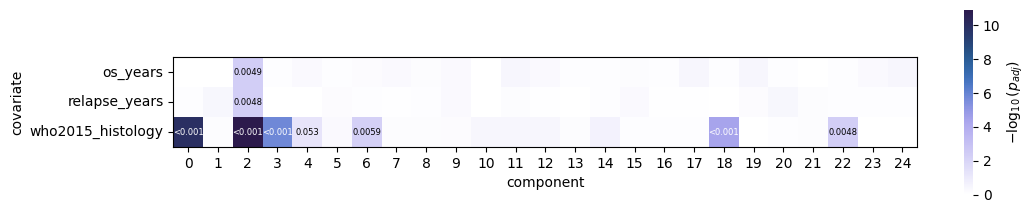

In [ ]:
ANNOTATION_THRESHOLD = 0.1
CAP_THRESHOLD = 0.001
wide_table = metadata_association.pivot_table(index="covariate", columns="component", values="nlog10_p_val_adj")

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
sns.heatmap(
    wide_table,
    square=True,
    cmap=apt.pl.BaseColormaps().get("sequential_r"),
    cbar_kws={"shrink": 0.6, "label": r"$-\log_{10}{(p_{adj})}$"},
    ax=ax,
    vmin=0,
)

# Label significant associations
wide_table = metadata_association.pivot_table(index="covariate", columns="component", values="p_val_adj")
for yi, xi in zip(*np.where(wide_table < ANNOTATION_THRESHOLD), strict=True):
    pval_adj = wide_table.iloc[yi, xi]
    text = f"{pval_adj:.2g}" if pval_adj > CAP_THRESHOLD else f"<{CAP_THRESHOLD}"
    ax.text(
        xi + 0.5,
        yi + 0.5,
        text,
        ha="center",
        va="center",
        color="#ffffff" if pval_adj < CAP_THRESHOLD else "#000000",
        fontsize=6,
    )

ax.spines[["top", "right", "left", "bottom"]].set_visible(True)

We see that the activity of factor 0 (explaining most variance in the model) varies significan associated with histological subtypes. This suggests that the histological cancer subtype is a major driver of variance across all omics layers. 

Factor 2 is further moderately correlated with overall survival of the patients and time to relapse. 

<Axes: title={'center': 'os years'}, xlabel='relapse_years', ylabel='mofa_factor_2'>

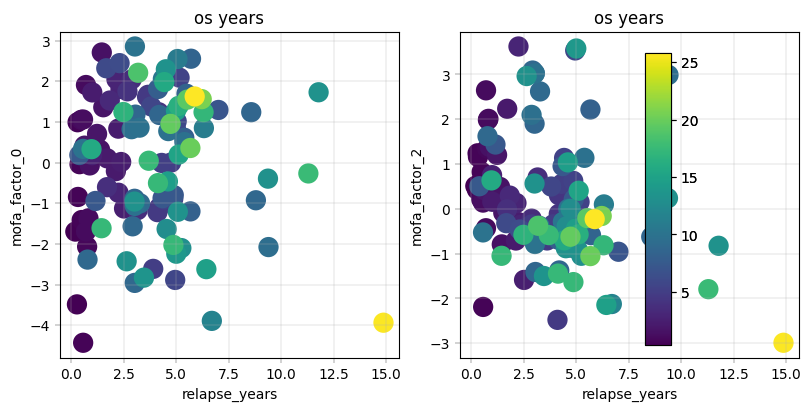

In [ ]:
mdata.obs["mofa_factor_0"] = mdata.obsm["X_mofa"][:, 0]
mdata.obs["mofa_factor_2"] = mdata.obsm["X_mofa"][:, 2]


fig, axm = apt.pl.create_figure(1, 2, figsize=(8, 4))
muon.pl.scatter(mdata, y="mofa_factor_0", x="relapse_years", color="os_years", ax=axm[0], show=False)
muon.pl.scatter(mdata, y="mofa_factor_2", x="relapse_years", color="os_years", ax=axm[1], show=False)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

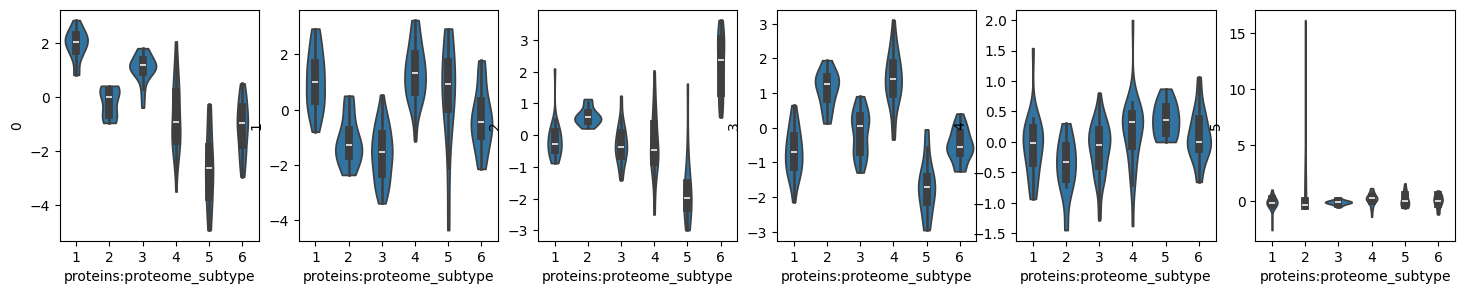

In [ ]:
df = pd.DataFrame(mdata.obsm["X_mofa"], index=mdata.obs_names).merge(mdata.obs, left_index=True, right_index=True)

fig, axs = plt.subplots(1, 6, figsize=(18, 3))
for col in range(6):
    sns.violinplot(df, y=col, x="proteins:proteome_subtype", ax=axs[col], cut=0)

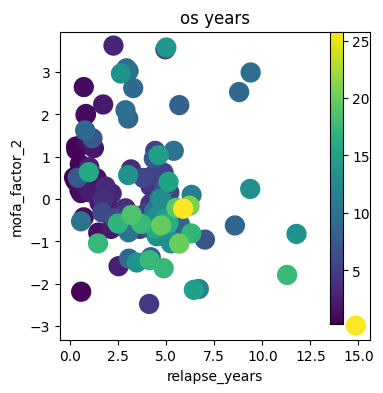

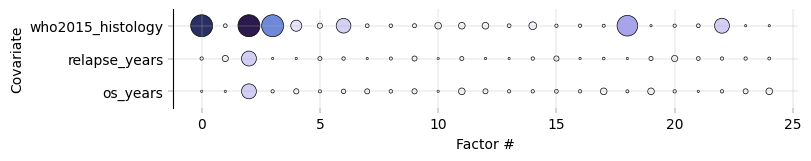

In [ ]:
# fig, axm = apt.pl.create_figure(1, 1, figsize=(8, 1.5))

# apt.pl.scatter(
#     metadata_association,
#     x_column="component",
#     y_column="covariate",
#     color_map_column="nlog10_p_val_adj",
#     scatter_kwargs={
#         "s": 200,
#         "s": np.clip(metadata_association["nlog10_p_val_adj"], 0.05, 5) * 50,
#         "edgecolor": "black",
#         "lw": 0.5,
#     },
#     palette=apt.pl.BaseColormaps().get("sequential_r"),
#     ax=axm[0],
#     legend="auto",
#     ylim=(-0.5, 2.5),
# )
# axm[0].spines[["top", "right", "bottom"]].set_visible(False)
# apt.pl.label_axes(ax=axm[0], xlabel="Factor #", ylabel="Covariate")

### Investigate factor loadings

Factor 0, 2, and 3 are strongly associated with histological subtype.

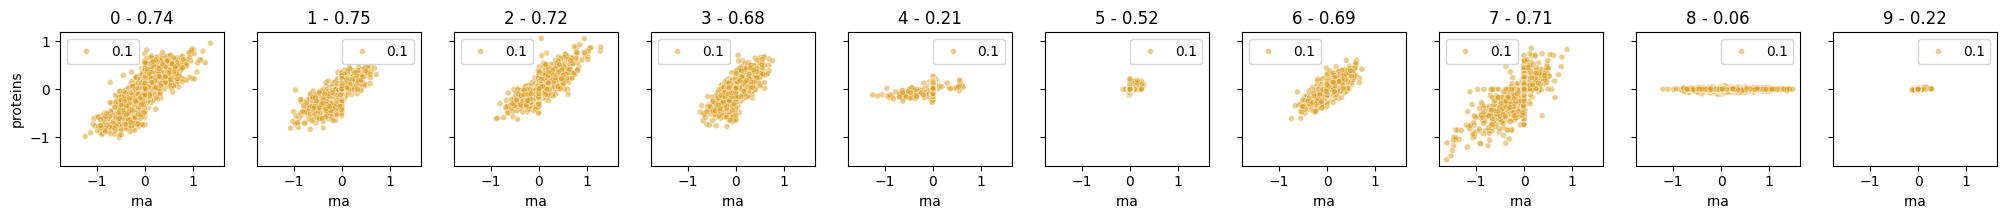

In [ ]:
mofa_loadings = pd.DataFrame(
    mdata.varm["LFs"], index=pd.MultiIndex.from_frame(mdata.var.reset_index(names="genes")[["genes", "modality"]])
).reset_index()

fig, axs = plt.subplots(1, 10, figsize=(25, 6), sharex=True, sharey=True)
for factor, ax in enumerate(axs.ravel()):
    factor0 = mofa_loadings.pivot_table(index="genes", columns="modality", values=factor).dropna(how="any")

    sns.scatterplot(factor0, x="rna", y="proteins", ax=ax, size=0.1, alpha=0.5, color="#de9d1b", lw=0.5)
    r2 = pearsonr(factor0["rna"], factor0["proteins"])
    ax.set_title(f"{factor} - {r2.statistic:.2f}")
    ax.set_aspect(1)

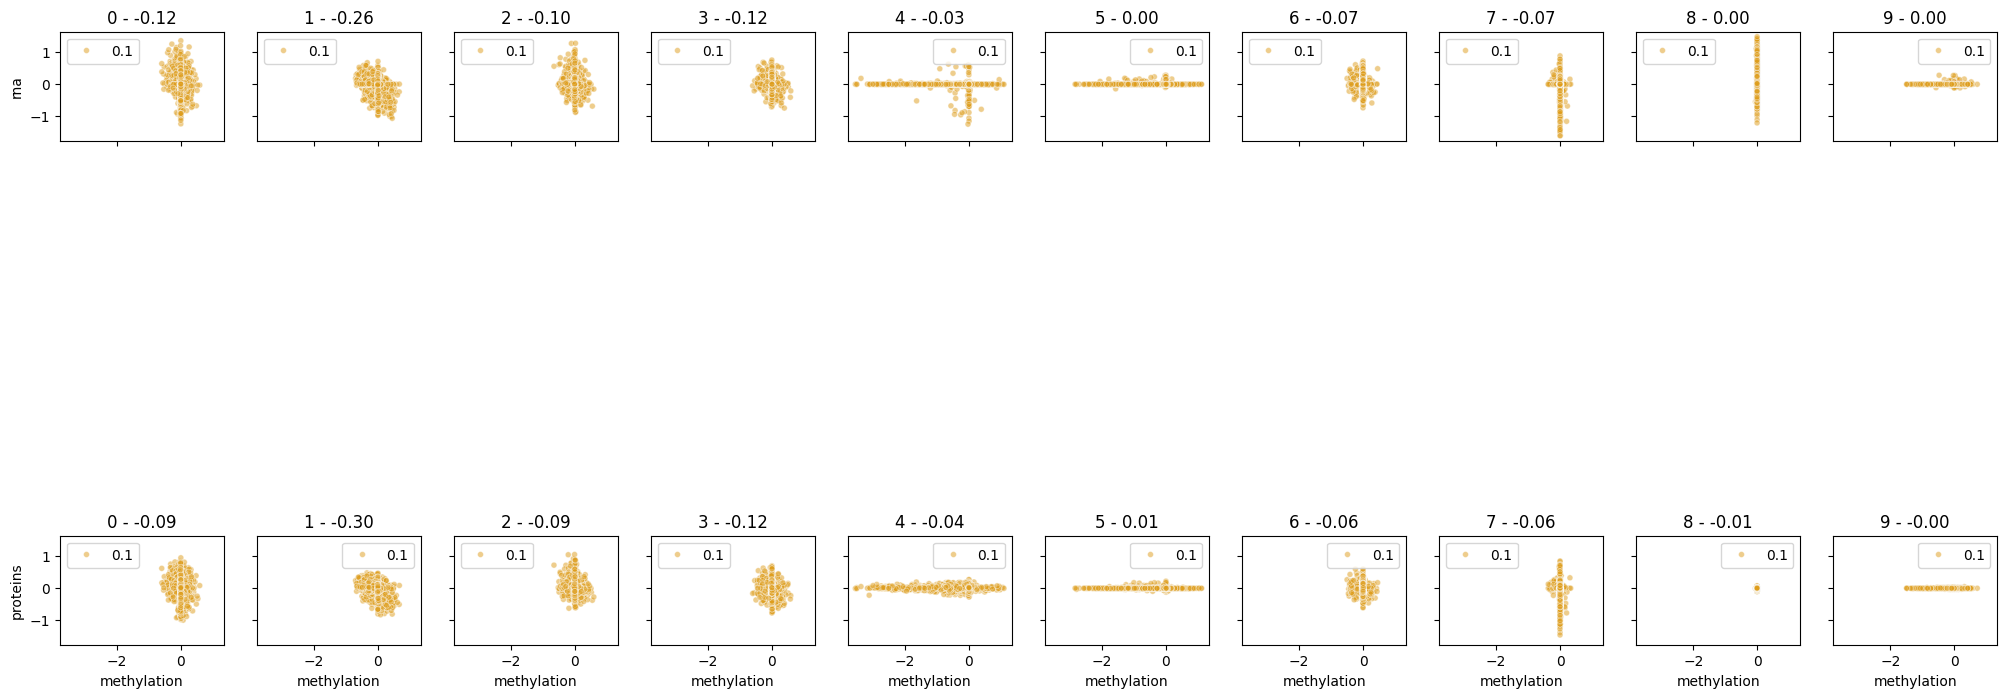

In [ ]:
mofa_loadings = pd.DataFrame(
    mdata.varm["LFs"], index=pd.MultiIndex.from_frame(mdata.var.reset_index(names="genes")[["genes", "modality"]])
).reset_index()

fig, axs = plt.subplots(2, 10, figsize=(25, 12), sharex=True, sharey=True)
for factor in range(10):
    factor0 = mofa_loadings.pivot_table(index="genes", columns="modality", values=factor).dropna(how="any")

    ax = axs[0, factor]
    sns.scatterplot(factor0, x="methylation", y="rna", ax=ax, size=0.1, alpha=0.5, color="#de9d1b", lw=0.5)
    r2 = pearsonr(factor0["rna"], factor0["methylation"])
    ax.set_title(f"{factor} - {r2.statistic:.2f}")
    ax.set_aspect(1)

    ax = axs[1, factor]
    sns.scatterplot(factor0, x="methylation", y="proteins", ax=ax, size=0.1, alpha=0.5, color="#de9d1b", lw=0.5)
    r2 = pearsonr(factor0["proteins"], factor0["methylation"])
    ax.set_title(f"{factor} - {r2.statistic:.2f}")
    ax.set_aspect(1)

### Separation of samples

We can check whether the joint modeling of proteomics, RNA, and methylation data improved the separation of samples based on their histological phenotype compared to _only_ the proteomics measurements. Here, we compute the _silhouette width_ of the histological subtypes on the MOFA+ embeddings for the multimodal modeling case and the proteomics-only modeling case, using the proteomics PCA embedding as a reference point.

The silhouette width ($s$) is a measure of how similar samples from the same condition are compared to samples from other conditions (separation). It ranges from −1 to +1, where higher values indicate better separation of conditions.

For comparison, we also compute principal components (PCA) and MOFA+ embedding for the single-modality measurements alone, using the same settings:

In [ ]:
# Run PCA
sc.pp.pca(methylation)
sc.pp.pca(rna)
apt.tl.pca(adata)

In [ ]:
# Run MOFA+
# Runs ca. 6 min on MacOS with M4
muon.tl.mofa(adata, **mofa_kwargs, outfile="mofa-proteomics.model.hdf5")
muon.tl.mofa(rna, **mofa_kwargs, outfile="mofa-rna.model.hdf5")
muon.tl.mofa(methylation, **mofa_kwargs, outfile="mofa-methylation.model.hdf5")


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Scaling views to unit variance...

Scaling groups to unit variance...

Loaded view='data' group='group1' with N=141 samples and D=9793 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: True
- Spike-and-slab prior on the weights: True
Likelihood

We compute the silhouette width on the top factors / principal components of each embedding. As the silhouette width is not well-behaved for very small groups, so we restrict the comparison to histological subtypes with more than 5 samples. This drops LCC (n=4) and SCLC (n=2), retaining AC, SqCC, and LCNEC. The results are qualitatively similar for other cutoffs.

In [ ]:
# Parameters, change them
min_group_size = 5

In [ ]:
# Define embeddings per model
embeddings = {
    "Methylation (PCA)": (methylation.obsm["X_pca"], methylation.obs["who2015_histology"]),
    "RNA (PCA)": (
        rna.obsm["X_pca"],
        rna.obs["who2015_histology"],
    ),
    "Proteins (PCA)": (adata.obsm["X_pca_obs"], adata.obs["who2015_histology"]),
    "Methylation (MOFA+)": (methylation.obsm["X_mofa"], methylation.obs["who2015_histology"]),
    "RNA (MOFA+)": (
        rna.obsm["X_mofa"],
        rna.obs["who2015_histology"],
    ),
    "Proteins (MOFA+)": (adata.obsm["X_mofa"], adata.obs["who2015_histology"]),
    "Joint (MOFA+)": (mdata.obsm["X_mofa"], mdata.obs["who2015_histology"]),
}

# To make modalities with partially matched samples comparable, we subset to the intersection of samples
intersecting_samples = set.intersection(
    set(adata.obs_names.tolist()), set(rna.obs_names.tolist()), set(methylation.obs_names.tolist())
)

# We subset to groups with a sufficient number of samples
group_sizes = metadata.value_counts("who2015_histology")
kept_groups = group_sizes.index[group_sizes > min_group_size]

records = []
for method, (embedding, labels) in embeddings.items():
    keep = (labels.index.isin(intersecting_samples) & labels.isin(kept_groups)).tolist()
    kept_embedding, kept_labels = embedding[keep], labels[keep]

    records.append(
        {
            "method": method,
            "silhouette_width": silhouette_score(kept_embedding, labels=kept_labels, metric="euclidean"),
            "n_groups": kept_labels.nunique(),
        }
    )

silhouette_scores = pd.DataFrame.from_records(records)
silhouette_scores

,method,silhouette_width,n_groups
0,Methylation (PCA),0.059916,3
1,RNA (PCA),0.128007,3
2,Proteins (PCA),0.094554,3
3,Methylation (MOFA+),0.084754,3
4,RNA (MOFA+),0.137201,3
5,Proteins (MOFA+),0.113013,3
6,Joint (MOFA+),0.154716,3


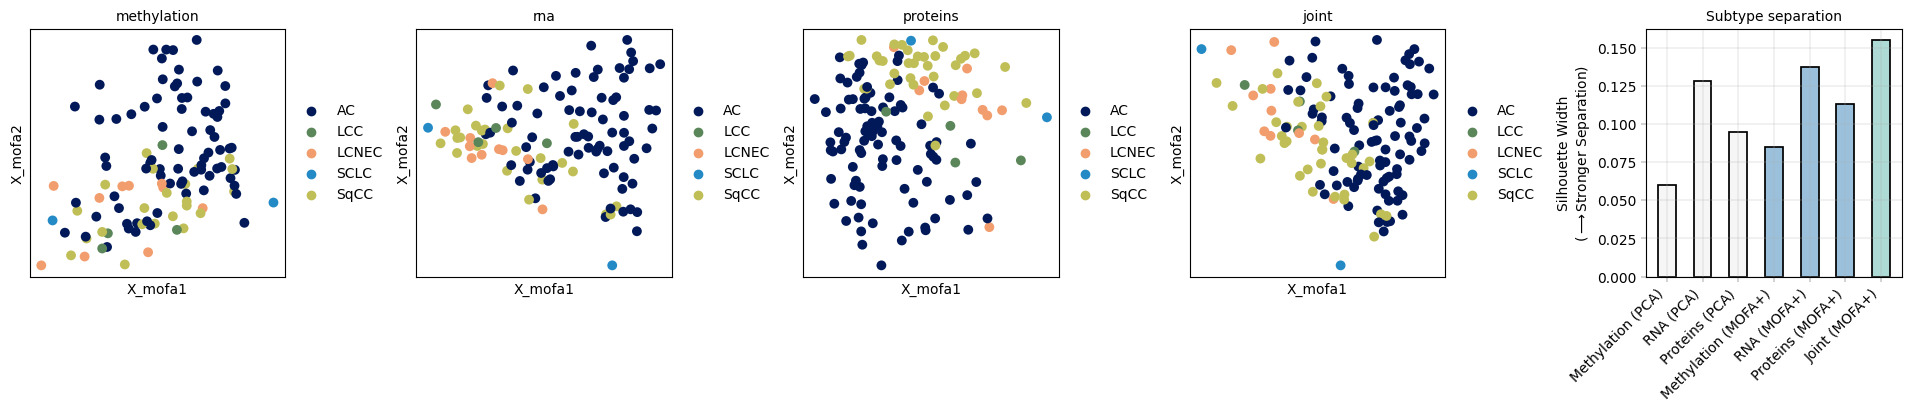

In [ ]:
plot_kwargs = {
    "basis": "X_mofa",
    "color": "who2015_histology",
    "size": 200,
    "palette": apt.pl.BasePalettes().get("qualitative"),
    "show": False,
    "title": "",
}
modalities = {"methylation": methylation.copy(), "rna": rna.copy(), "proteins": adata.copy(), "joint": mdata.copy()}

fig, axm = apt.pl.create_figure(1, 5, figsize=(19, 4))

for idx, (modality, data) in enumerate(modalities.items()):
    muon.pl.embedding(data, ax=axm[idx], **plot_kwargs)
    apt.pl.label_axes(ax=axm[idx], title=modality)


apt.pl.barplot(
    ax=axm[4],
    data=silhouette_scores,
    value_column="silhouette_width",
    grouping_column="method",
    color_dict={
        "Methylation (PCA)": "#eeeeee",
        "RNA (PCA)": "#eeeeee",
        "Proteins (PCA)": "#eeeeee",
        "Methylation (MOFA+)": apt.pl.BaseColors.get("blue"),
        "RNA (MOFA+)": apt.pl.BaseColors.get("blue"),
        "Proteins (MOFA+)": apt.pl.BaseColors.get("blue"),
        "Joint (MOFA+)": apt.pl.BaseColors.get("green"),
    },
)
apt.pl.label_axes(
    ax=axm[4],
    ylabel="Silhouette Width\n($\\longrightarrow$Stronger Separation)",
    title="Subtype separation",
)
plt.xticks(rotation=45, ha="right")
plt.show()

The silhouette width analysis suggests that the joint modeling of the three available modalities improves the separation of histological subtypes **moderately** compared to the individual modalities.

That the integration of the multimodal data does not lead to a stronger separation of histological subtypes can have different reasons: 
1. Histology is a strong phenotype that is already well separated by each individual modality, so the separation might "top out" at a certain value, independent of the modality. 
2. As the original authors noted, there is additional molecular heterogeneity beyond the histological phenotype that cannot be resolved by the histological assessment. 

## Summary

## Session Info 

In [ ]:
from session_info2 import session_info

session_info()